In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [2]:
df = pd.read_csv(r"D:\SEM_VI\PATTERN_REC\weather_forecast_data.csv")
print(df.shape)
print(df.head())
print(df['Rain'].value_counts())

(2500, 6)
   Temperature   Humidity  Wind_Speed  Cloud_Cover     Pressure     Rain
0    23.720338  89.592641    7.335604    50.501694  1032.378759     rain
1    27.879734  46.489704    5.952484     4.990053   992.614190  no rain
2    25.069084  83.072843    1.371992    14.855784  1007.231620  no rain
3    23.622080  74.367758    7.050551    67.255282   982.632013     rain
4    20.591370  96.858822    4.643921    47.676444   980.825142  no rain
Rain
no rain    2186
rain        314
Name: count, dtype: int64


In [3]:
le = LabelEncoder()
df['Rain'] = le.fit_transform(df['Rain'])  # rain=1, no rain=0

X = df.drop('Rain', axis=1)
y = df['Rain']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

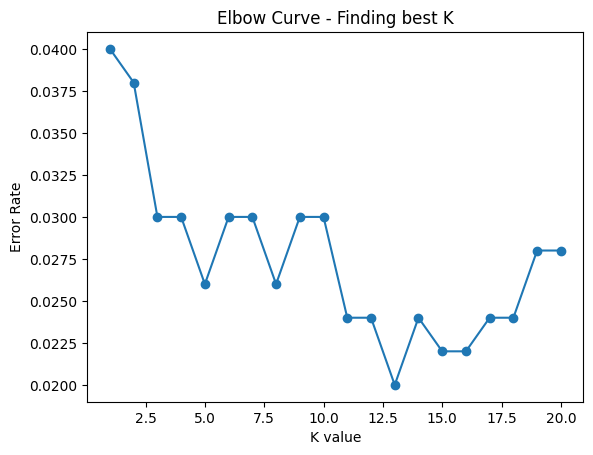

In [6]:
error_rates = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    error_rates.append(1 - knn.score(X_test, y_test))

plt.plot(range(1, 21), error_rates, marker='o')
plt.xlabel('K value')
plt.ylabel('Error Rate')
plt.title('Elbow Curve - Finding best K')
plt.show()

0.974
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       443
           1       0.88      0.89      0.89        57

    accuracy                           0.97       500
   macro avg       0.93      0.94      0.94       500
weighted avg       0.97      0.97      0.97       500



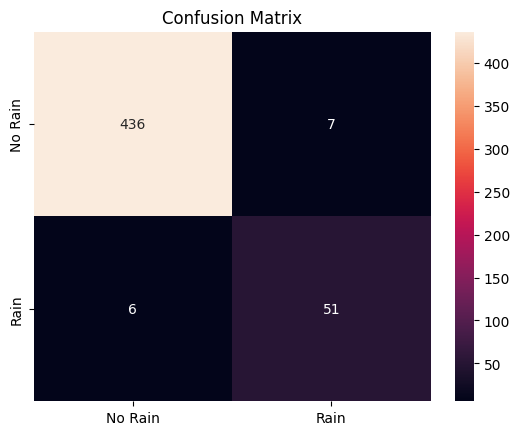

In [7]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['No Rain','Rain'],
            yticklabels=['No Rain','Rain'])
plt.title('Confusion Matrix')
plt.show()